<a href="https://colab.research.google.com/github/Inesvvv/ML_Project/blob/main/Logistic_Regression_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train shape: (603, 753)
Test shape:  (153, 753)

Features remaining after correlation filter: 539
Dummy baseline accuracy: 0.725


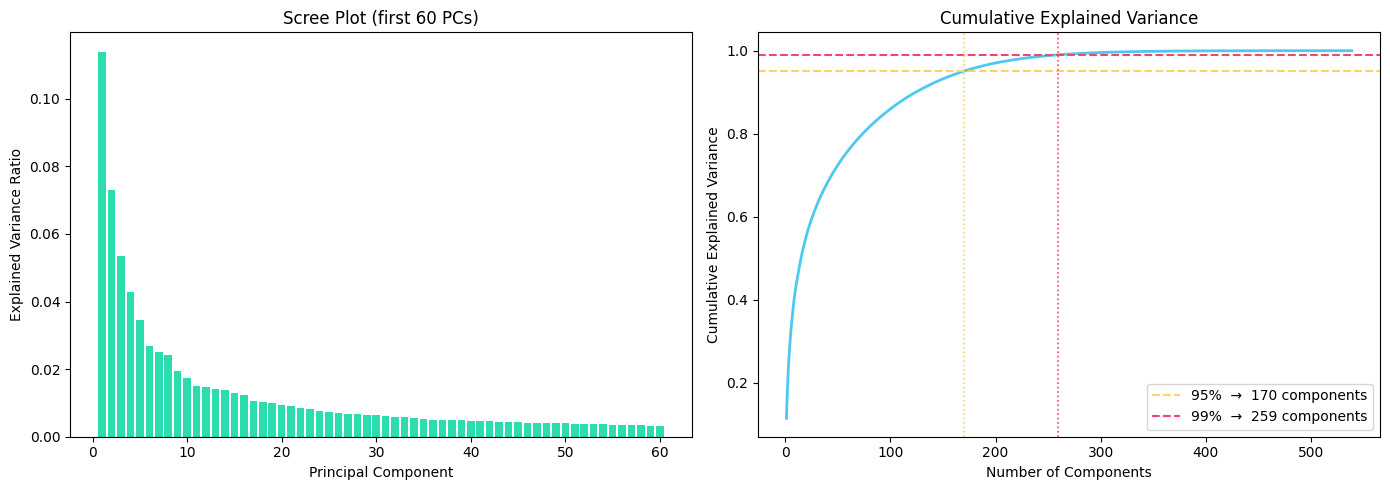


Components for 95% variance: 170
Components for 99% variance: 259

PCA: 170 components  (95.1% of variance retained)

              precision    recall  f1-score   support

           0       0.83      0.45      0.58        42
           1       0.82      0.96      0.89       111

    accuracy                           0.82       153
   macro avg       0.82      0.71      0.74       153
weighted avg       0.82      0.82      0.80       153

Test ROC-AUC: 0.9015


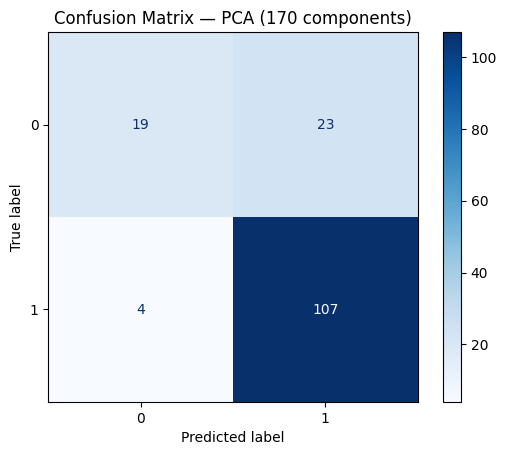

In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, ConfusionMatrixDisplay
)

# Load data
drive.mount('/content/drive')

df = pd.read_csv(
    "/content/drive/MyDrive/Machine_Learning_Project/ML_notebooks/pd_speech_features.csv",
    skiprows=1
)

X      = df.drop(columns=["class", "id"])
y      = df["class"]
groups = df["id"]

# Grouped train / test split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")

# Correlation filter  (remove features correlated > 0.96)
corr   = X_train.corr().abs()
upper  = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.96)]
X_train = X_train.drop(columns=to_drop)
X_test  = X_test.drop(columns=to_drop)

print(f"\nFeatures remaining after correlation filter: {X_train.shape[1]}")

# Dummy baseline
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
print(f"Dummy baseline accuracy: {dummy.score(X_test, y_test):.3f}")

# PCA — inspect explained variance to choose n_components
scaler_tmp   = StandardScaler()
X_train_sc   = scaler_tmp.fit_transform(X_train)

pca_full     = PCA().fit(X_train_sc)
cumvar        = np.cumsum(pca_full.explained_variance_ratio_)

n_95 = int(np.searchsorted(cumvar, 0.95)) + 1
n_99 = int(np.searchsorted(cumvar, 0.99)) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, 61), pca_full.explained_variance_ratio_[:60],
            color="#06D6A0", alpha=0.85)
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].set_title("Scree Plot (first 60 PCs)")

# Cumulative variance
axes[1].plot(range(1, len(cumvar) + 1), cumvar, color="#4CC9F0", lw=2)
axes[1].axhline(0.95, color="#FFD166", ls="--", lw=1.5, label=f"95%  →  {n_95} components")
axes[1].axhline(0.99, color="#EF476F", ls="--", lw=1.5, label=f"99%  →  {n_99} components")
axes[1].axvline(n_95, color="#FFD166", ls=":", lw=1.2)
axes[1].axvline(n_99, color="#EF476F", ls=":", lw=1.2)
axes[1].legend(fontsize=10)
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].set_title("Cumulative Explained Variance")

plt.tight_layout()
plt.show()

print(f"\nComponents for 95% variance: {n_95}")
print(f"Components for 99% variance: {n_99}")


N_COMPONENTS = n_95

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca",    PCA(n_components=N_COMPONENTS, random_state=42)),
    ("model",  LogisticRegression(
                   C=0.001, solver="lbfgs", penalty="l2",
                   max_iter=5000, class_weight="balanced"
               ))
])
pipe.fit(X_train, y_train)

# Evaluate
proba = pipe.predict_proba(X_test)[:, 1]
pred  = (proba >= 0.32).astype(int)

print(f"\nPCA: {N_COMPONENTS} components  "
      f"({cumvar[N_COMPONENTS - 1] * 100:.1f}% of variance retained)\n")
print(classification_report(y_test, pred))
print(f"Test ROC-AUC: {roc_auc_score(y_test, proba):.4f}")

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, pred, cmap="Blues")
plt.title(f"Confusion Matrix — PCA ({N_COMPONENTS} components)")
plt.show()

### Note on File Path
If your file is inside a specific folder in your Drive, you may need to update the path below to something like `'/content/drive/MyDrive/YourFolderName/pd_speech_features.csv'`. Currently, I've updated it to look in the root of your MyDrive.